In [ ]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%pip install statsmodels
%pip install arch

In [2]:
# Hedged Forward Spot (net portfolio)
hedged_forward_spot_df = pd.read_csv(
    'Profit and Loss/hedged_forward_spot.csv',
    parse_dates=['Pricing_Date']
)

# Hedged RR Spot (net portfolio)
hedged_rr45_spot_df = pd.read_csv(
    'Profit and Loss/hedged_rr45_spot.csv',
    parse_dates=['Pricing_Date']
)

# Hedged RR Delta (net portfolio)
hedged_rr45_delta_df = pd.read_csv(
    'Profit and Loss/hedged_rr45_delta.csv',
    parse_dates=['Pricing_Date']
)

# Unhedged (physical portfolio)
unhedged_df = pd.read_csv(
    'Profit and Loss/unhedged_complete_pnl.csv',
    parse_dates=['Pricing_Date']
)

In [5]:
# spot prices

spot_df = pd.read_csv(
    'Market Data/spot_price.csv',
    parse_dates=['Pricing_Date'],
    dayfirst=True
)

## Regimes

### Spot Regimes - Bry Boschan Turning Point Dating

In [7]:
# =============================================================================
# SPOT REGIME CELLS — two-state (APPRECIATION / DEPRECIATION)
# Requires: bry_boschan_dating.py (updated, no RANGE), spot_price.csv
# =============================================================================

# --- Cell 1: Baseline specification ------------------------------------------
import pandas as pd
from bry_boschan_dating import run, BASELINE, NAIVE_RESCALE

SPOT_PATH = 'Market Data/spot_price.csv'
PRICE_COL = 'Current_Spot'          # spot level column in spot_price.csv
DATE_COL  = 'Pricing_Date'

params_baseline = dict(BASELINE)   # window=14, min_phase=25, min_cycle=100, end_buffer=14

df_spot, tps, phases, daily_regime = run(SPOT_PATH, params=params_baseline)


def turning_points_table(df, tps, date_col=DATE_COL, price_col=PRICE_COL):
    """Map each (position, kind) turning point to its date and spot level."""
    df = df.sort_values(date_col).reset_index(drop=True)
    dates  = df[date_col].to_numpy()
    levels = df[price_col].to_numpy()
    rows = []
    for pos, kind in sorted(tps, key=lambda x: x[0]):
        rows.append({
            "date":  pd.Timestamp(dates[pos]).date(),
            "type":  "Peak" if kind == "P" else "Trough",
            "spot":  round(float(levels[pos]), 4),
        })
    return pd.DataFrame(rows)


tp_table = turning_points_table(df_spot, tps)

print(f"BASELINE: {len(tps)} turning points, {len(phases)} phases\n")
print("Turning points (date, type, spot level):")
print(tp_table.to_string(index=False))
print("\nPhases:")
print(phases[["start_date", "end_date", "duration_days", "pct_move", "regime"]].to_string())


# --- Cell 2: Daily regime counts (baseline) ----------------------------------
print(daily_regime.value_counts())


# --- Cell 3: Naive rescaling robustness check --------------------------------
df_naive, tps_naive, phases_naive, _ = run(SPOT_PATH, params=NAIVE_RESCALE)

print(f"\nNAIVE RESCALE: {len(tps_naive)} turning points, {len(phases_naive)} phases")
if len(phases_naive) > 0:
    print("\nTurning points (date, type, spot level):")
    print(turning_points_table(df_naive, tps_naive).to_string(index=False))
    print("\nPhases:")
    print(phases_naive[["start_date", "end_date", "duration_days", "pct_move", "regime"]].to_string())
else:
    print("No complete phases dated — end_buffer censors all turning points.")
    print("(Expected: with min_cycle=352d, the algorithm requires cycles longer")
    print(" than the full sample divided by ~2, yielding 0-2 phases at most.)")

BASELINE: 11 turning points, 10 phases

Turning points (date, type, spot level):
      date   type   spot
2021-05-28 Trough 6.3603
2021-07-27   Peak 6.5269
2022-02-23 Trough 6.3121
2022-11-02   Peak 7.3430
2023-01-13 Trough 6.7139
2023-09-08   Peak 7.3647
2023-12-28 Trough 7.1183
2024-07-02   Peak 7.3070
2024-09-26 Trough 6.9730
2025-04-08   Peak 7.4257
2026-02-26 Trough 6.8444

Phases:
  start_date   end_date  duration_days  pct_move        regime
0 2021-05-28 2021-07-27             42  0.026194  DEPRECIATION
1 2021-07-27 2022-02-23            151 -0.032910  APPRECIATION
2 2022-02-23 2022-11-02            180  0.163321  DEPRECIATION
3 2022-11-02 2023-01-13             52 -0.085673  APPRECIATION
4 2023-01-13 2023-09-08            170  0.096933  DEPRECIATION
5 2023-09-08 2023-12-28             77 -0.033457  APPRECIATION
6 2023-12-28 2024-07-02            132  0.026509  DEPRECIATION
7 2024-07-02 2024-09-26             62 -0.045710  APPRECIATION
8 2024-09-26 2025-04-08            136  0.0

In [8]:
# --- Cell 4: Expanded sensitivity grid --------------------------------------
# Parameter ranges derived from the 3M rolling-hedge horizon (trading-day units):
#   window    : shortest reversal a 3M-rolling hedger would act on.
#               7d (~1.5wk, noise floor) -> 42d (~2mo, over-smoothing probe).
#   min_phase : a phase must persist long enough to be hedgeable.
#               15d (sub-hedge noise floor) -> 63d (one full 3M hedge tenor, ceiling).
# min_cycle held at 100 here; varied separately in Cell 4b.
# end_buffer (14) and amp_override (0.04) held fixed.
#
# The eight interior turning points (Feb 2022 - Apr 2025) are the claim under test:
# they should survive across the entire economically-plausible interior of the grid.

import itertools
import pandas as pd

windows    = [7, 10, 14, 21, 28, 42]    # ~1.5 weeks to ~2 months
min_phases = [15, 25, 35, 50, 63]       # noise floor to one 3M hedge tenor

# Load the spot dates once (not inside the loop).
df_tp = pd.read_csv(SPOT_PATH)
df_tp['Pricing_Date'] = pd.to_datetime(df_tp['Pricing_Date'], dayfirst=True)
df_tp = df_tp.sort_values('Pricing_Date').reset_index(drop=True)
dates_arr = df_tp['Pricing_Date'].to_numpy()

# The eight robust interior turning points to track explicitly.
INTERIOR_8 = {
    pd.Timestamp('2022-02-23').date(), pd.Timestamp('2022-11-02').date(),
    pd.Timestamp('2023-01-13').date(), pd.Timestamp('2023-09-08').date(),
    pd.Timestamp('2023-12-28').date(), pd.Timestamp('2024-07-02').date(),
    pd.Timestamp('2024-09-26').date(), pd.Timestamp('2025-04-08').date(),
}

grid_rows = []
tp_date_rows = []

for w, mp in itertools.product(windows, min_phases):
    p = dict(BASELINE)
    p['window']    = w
    p['min_phase'] = mp

    _, tps_g, phases_g, _ = run(SPOT_PATH, params=p)

    tp_dates_this_spec = set()
    for pos, kind in tps_g:
        d = pd.Timestamp(dates_arr[pos]).date()
        tp_dates_this_spec.add(d)
        tp_date_rows.append({'window': w, 'min_phase': mp, 'tp_date': d, 'kind': kind})

    grid_rows.append({
        'window': w,
        'min_phase': mp,
        'n_phases': len(phases_g),
        'n_tp': len(tps_g),
        'dep_phases': (phases_g['regime'] == 'DEPRECIATION').sum() if len(phases_g) else 0,
        'app_phases': (phases_g['regime'] == 'APPRECIATION').sum() if len(phases_g) else 0,
        'interior_8_recovered': len(INTERIOR_8 & tp_dates_this_spec),  # out of 8
    })

grid_df = pd.DataFrame(grid_rows)
tp_dates_df = pd.DataFrame(tp_date_rows)
n_specs = len(grid_df)

print(f"Total specifications: {n_specs}")

print("\n--- Phase count grid (window x min_phase) ---")
print(grid_df.pivot(index='min_phase', columns='window', values='n_phases').to_string())

print("\n--- Interior-8 recovery grid (max 8) ---")
print(grid_df.pivot(index='min_phase', columns='window', values='interior_8_recovered').to_string())

print("\n--- Full grid summary ---")
print(grid_df.to_string(index=False))


# --- Cell 4b: min_cycle robustness check (baseline window/min_phase) --------
# Confirm the interior eight are not an artefact of min_cycle=100.
# Vary min_cycle at the baseline window=14, min_phase=25.

print("\n\n--- min_cycle check at baseline window=14, min_phase=25 ---")
for mc in [80, 100, 120]:
    p = dict(BASELINE)
    p['min_cycle'] = mc
    _, tps_mc, phases_mc, _ = run(SPOT_PATH, params=p)
    dts = {pd.Timestamp(dates_arr[pos]).date() for pos, _ in tps_mc}
    print(f"min_cycle={mc}: {len(phases_mc)} phases, "
          f"interior-8 recovered = {len(INTERIOR_8 & dts)}/8")




Total specifications: 30

--- Phase count grid (window x min_phase) ---
window     7   10  14  21  28  42
min_phase                        
15         11  10  12  11  11   7
25          9  10  10   9   9   7
35          9  10  10   9   9   7
50          7   8   8   7   7   7
63          7   8   8   7   7   7

--- Interior-8 recovery grid (max 8) ---
window     7   10  14  21  28  42
min_phase                        
15          8   8   8   8   8   8
25          8   8   8   8   8   8
35          8   8   8   8   8   8
50          8   8   8   8   8   8
63          8   8   8   8   8   8

--- Full grid summary ---
 window  min_phase  n_phases  n_tp  dep_phases  app_phases  interior_8_recovered
      7         15        11    12           6           5                     8
      7         25         9    10           5           4                     8
      7         35         9    10           5           4                     8
      7         50         7     8           4           3 

In [9]:
# --- Cell 5: Turning-point stability across the expanded grid ----------------
stability = (
    tp_dates_df
    .groupby(['tp_date', 'kind'])
    .size()
    .reset_index(name='n_specs')
    .sort_values('tp_date')
)
stability['pct_specs'] = (100 * stability['n_specs'] / n_specs).round(0).astype(int)
stability['is_interior_8'] = stability['tp_date'].isin(INTERIOR_8)

print("\n--- Turning-point date stability (max =", n_specs, "specs) ---")
print(stability.to_string(index=False))

print("\n--- Interior eight: recovery across all specs ---")
print(stability[stability['is_interior_8']].to_string(index=False))

print("\n--- Non-interior turning points (2021 pair + recent-tail dates) ---")
print(stability[~stability['is_interior_8']].to_string(index=False))


--- Turning-point date stability (max = 30 specs) ---
   tp_date kind  n_specs  pct_specs  is_interior_8
2021-05-28    T       15         50          False
2021-07-27    P       15         50          False
2022-02-23    T       30        100           True
2022-11-02    P       30        100           True
2023-01-13    T       30        100           True
2023-09-08    P       30        100           True
2023-12-28    T       30        100           True
2024-07-02    P       30        100           True
2024-09-26    T       30        100           True
2025-04-08    P       30        100           True
2025-09-17    T        4         13          False
2025-10-08    P        4         13          False
2025-10-28    T        5         17          False
2026-02-26    T        5         17          False

--- Interior eight: recovery across all specs ---
   tp_date kind  n_specs  pct_specs  is_interior_8
2022-02-23    T       30        100           True
2022-11-02    P       30   

In [10]:
# --- Cell 6: Baseline phase table for thesis ---------------------------------
# Clean display of the baseline phases for the results chapter.
# UNCLASSIFIED breakdown: pre-first-turn buffer (early 2021) and
# open final phase (post last dated turn ~Feb 2026).
# The open final phase is assigned a PROVISIONAL direction label for
# narrative only and excluded from all statistical inference.

show = phases.copy()
show['start_date'] = pd.to_datetime(show['start_date']).dt.date
show['end_date']   = pd.to_datetime(show['end_date']).dt.date
show['pct_move']   = (show['pct_move'] * 100).round(2)

print("\n--- Baseline phase table ---")
print(show[['start_date', 'end_date', 'duration_days', 'pct_move', 'regime']].to_string(index=False))

unclassified_count = (daily_regime == 'UNCLASSIFIED').sum()
print(f"\nUNCLASSIFIED trading days: {unclassified_count}")
print("  - Pre-first-turn buffer: early sample before first dated turning point")
print("  - Open final phase: recent tail after last confirmed turning point")
print("  (Both excluded from spot-regime inference; carry and vol labels remain defined.)")


--- Baseline phase table ---
start_date   end_date  duration_days  pct_move       regime
2021-05-28 2021-07-27             42      2.62 DEPRECIATION
2021-07-27 2022-02-23            151     -3.29 APPRECIATION
2022-02-23 2022-11-02            180     16.33 DEPRECIATION
2022-11-02 2023-01-13             52     -8.57 APPRECIATION
2023-01-13 2023-09-08            170      9.69 DEPRECIATION
2023-09-08 2023-12-28             77     -3.35 APPRECIATION
2023-12-28 2024-07-02            132      2.65 DEPRECIATION
2024-07-02 2024-09-26             62     -4.57 APPRECIATION
2024-09-26 2025-04-08            136      6.49 DEPRECIATION
2025-04-08 2026-02-26            229     -7.83 APPRECIATION

UNCLASSIFIED trading days: 66
  - Pre-first-turn buffer: early sample before first dated turning point
  - Open final phase: recent tail after last confirmed turning point
  (Both excluded from spot-regime inference; carry and vol labels remain defined.)


### Volatility Regimes

In [11]:
# spot_df: columns Pricing_Date, Current_Spot ; one row per trading day, sorted
LAMBDA, ANN, SEED_N = 0.94, 252, 21   # lambda=0.94 -> half-life ~11d, centre-of-mass ~16d
OUT_PATH = "Market Data/spot_price_with_volatility.csv"

spot_df = spot_df.sort_values("Pricing_Date").reset_index(drop=True)
spot_df["Log_Return"] = np.log(spot_df["Current_Spot"]).diff()
r = spot_df["Log_Return"]

# (A) RiskMetrics EWMA -- the standard, citable form (zero-mean):
#     sigma2_t = LAMBDA*sigma2_{t-1} + (1-LAMBDA)*r_t^2
r2 = r.pow(2).to_numpy()
sig2 = np.full(len(r2), np.nan)
sig2[SEED_N] = np.nanmean(r2[1:SEED_N + 1])          # seed on first SEED_N squared returns
for t in range(SEED_N + 1, len(r2)):
    sig2[t] = LAMBDA * sig2[t - 1] + (1 - LAMBDA) * r2[t]
ewma_zeromean = np.sqrt(sig2 * ANN)

# (B) de-trended EWMA -- consistent with your rolling-std (mean-subtracted) choice:
ewma_detrended = r.ewm(alpha=1 - LAMBDA, adjust=False).std(bias=True) * np.sqrt(ANN)

spot_df["Realized_Vol_EWMA"] = ewma_zeromean        # swap if needed
spot_df.to_csv(OUT_PATH, index=False)
spot_df[["Pricing_Date", "Current_Spot", "Log_Return", "Realized_Vol_EWMA"]].iloc[18:28]

,Pricing_Date,Current_Spot,Log_Return,Realized_Vol_EWMA
18,2021-05-10,6.4221,0.000935,NaN
19,2021-05-11,6.4288,0.001043,NaN
20,2021-05-12,6.4588,0.004656,NaN
21,2021-05-13,6.4481,-0.001658,0.039104
22,2021-05-14,6.4378,-0.001599,0.038419
23,2021-05-17,6.4425,0.000730,0.037357
24,2021-05-18,6.4217,-0.003234,0.038339
25,2021-05-19,6.4402,0.002877,0.038818
26,2021-05-20,6.4339,-0.000979,0.037827
27,2021-05-21,6.4368,0.000451,0.036717


In [12]:

VOL_COL = "Realized_Vol_EWMA"          # the column you just built
v = spot_df[VOL_COL]

# tercile cut points from the full-sample distribution (NaNs skipped automatically)
q33, q66 = v.quantile([1/3, 2/3])      # -> 0.0312, 0.0481 on your data

spot_df["Vol_Regime"] = pd.cut(
    v, bins=[-np.inf, q33, q66, np.inf],
    labels=["LOW", "MED", "HIGH"],
)

# burn-in / NaN vol days have no tercile -> label them explicitly,
# mirroring the UNCLASSIFIED bucket in your directional regimes
spot_df["Vol_Regime"] = (spot_df["Vol_Regime"]
                         .cat.add_categories("UNCLASSIFIED")
                         .fillna("UNCLASSIFIED"))

print(f"thresholds: q33 = {q33:.4f}, q66 = {q66:.4f}")
print(spot_df["Vol_Regime"].value_counts())

thresholds: q33 = 0.0312, q66 = 0.0481
Vol_Regime
HIGH            426
LOW             425
MED             425
UNCLASSIFIED     21
Name: count, dtype: int64


### Carry Regimes

In [10]:
# --- carry regimes (positive vs negative) ------------------------
# Sign of the annualised 3M carry. The carry crossed from positive to negative
# on 6 July 2022 (dated precisely from the daily forward data); positive before,
# negative from that date onward. No burn-in / UNCLASSIFIED bucket is needed:
# the sign is defined over the whole sample.

CARRY_FLIP = pd.Timestamp("2022-07-06")

### Tag PnL Dataframes by Regime

In [11]:
# --- Cell 3: tag a P&L dataframe by regime -------------------------------

# 1. Build a dense daily calendar spanning the full P&L date range
all_dates = pd.date_range(
    start=hedged_forward_spot_df["Pricing_Date"].min(),
    end=hedged_forward_spot_df["Pricing_Date"].max(),
    freq="D"
)

# 2. Reindex the spot regime series onto that calendar, then forward-fill.
#    daily_regime is a Series indexed by Pricing_Date (trading days only).
spot_regime_filled = (
    daily_regime
    .reindex(all_dates)      # introduces NaN on weekends/holidays
    .ffill()                 # each non-trading day inherits the previous trading day
)
spot_regime_filled.index.name = "Pricing_Date"

# 3. Do the same for the vol regime (currently on spot_df trading days only).
vol_regime_filled = (
    spot_df.set_index("Pricing_Date")["Vol_Regime"]
    .reindex(all_dates)
    .ffill()
)
vol_regime_filled.index.name = "Pricing_Date"

# Works for any of your strategy frames (forward, rr45_spot, rr45_delta, unhedged).

def add_regimes(pnl_df, date_col="Pricing_Date"):
    pnl_df = pnl_df.copy()
    pnl_df[date_col] = pd.to_datetime(pnl_df[date_col], dayfirst=True)
    pnl_df["spot_regime"] = pnl_df[date_col].map(spot_regime_filled)
    pnl_df["vol_regime"]  = pnl_df[date_col].map(vol_regime_filled)
    pnl_df["carry_regime"] = np.where(
        pnl_df[date_col] < CARRY_FLIP, "POSITIVE", "NEGATIVE"
    )
    # Any date before the first trading day (before series starts) stays NaN;
    # label explicitly so downstream filters catch it.
    for col in ("spot_regime", "vol_regime"):
        pnl_df[col] = pnl_df[col].fillna("UNCLASSIFIED")
    return pnl_df

hedged_rr45_spot_df    = add_regimes(hedged_rr45_spot_df)
hedged_rr45_delta_df   = add_regimes(hedged_rr45_delta_df)
hedged_forward_spot_df = add_regimes(hedged_forward_spot_df)
unhedged_df            = add_regimes(unhedged_df)

# Sanity check: UNCLASSIFIED should now be only the genuine gaps
#    (before the first turning point and the open final phase).
print(hedged_forward_spot_df["spot_regime"].value_counts())
print(hedged_forward_spot_df["vol_regime"].value_counts())
print(hedged_forward_spot_df["carry_regime"].value_counts())

spot_regime
DEPRECIATION    931
APPRECIATION    804
UNCLASSIFIED     92
Name: count, dtype: int64
vol_regime
MED             608
LOW             595
HIGH            595
UNCLASSIFIED     29
Name: count, dtype: int64
carry_regime
NEGATIVE    1379
POSITIVE     448
Name: count, dtype: int64


## Confirming Dataframes

In [12]:
# Save dataframes to confirm the new columns are there

hedged_rr45_spot_df.to_csv('Regimes/hedged_rr45_spot_regimes.csv', index=False)
hedged_rr45_delta_df.to_csv('Regimes/hedged_rr45_delta_regimes.csv', index=False)
hedged_forward_spot_df.to_csv('Regimes/hedged_forward_spot_regimes.csv', index=False)
unhedged_df.to_csv('Regimes/unhedged_regimes.csv', index=False)

# Analysis

In [13]:
# --- Run the full statistical analysis from this notebook ----------------
# Requires analysis.py and metrics.py in the same folder as this notebook
# (or on sys.path). Re-run this cell after any edit to analysis.py / metrics.py.

import importlib
import analysis, metrics
importlib.reload(metrics)
importlib.reload(analysis)

import os
import pandas as pd

# Pass your in-memory regime-tagged frames + the pure trading-day calendar.
# Each frame needs Pricing_Date, the three regime columns, and
# Portfolio_Cumulative_PnL. spot_df supplies the trading-day calendar so the
# calendar-day (weekend-filled) rows are dropped before any metric is computed.
frames = {
    "forward":  hedged_forward_spot_df,
    "rr_spot":  hedged_rr45_spot_df,
    "rr_delta": hedged_rr45_delta_df,
    "unhedged": unhedged_df,
}

res = analysis.run_all(
    B=10_000,                        # bootstrap replicates (set 1000 to test)
    frames=frames,
    spot_dates=spot_df["Pricing_Date"],
)

# Pull out the results
differences    = res["differences"]      # RR - forward diff metrics, CIs + verdict
sortino_levels = res["sortino_levels"]   # per-strategy Sortino, each with its own CI
points         = res["points"]           # full metric set, every strategy x regime
boot_dist      = res["boot_dist"]        # raw replicate arrays (differences)
sortino_dist   = res["sortino_dist"]     # raw replicate arrays (Sortino levels)

# ---- The full set of parallel one-dimensional regimes (RANGE removed) -------
regimes = [
    "full",
    "spot:APPRECIATION", "spot:DEPRECIATION",
    "vol:LOW", "vol:MED", "vol:HIGH",
    "carry:POSITIVE", "carry:NEGATIVE",
]

# ---- Headline: appreciation regime (spot) -----------------------------------
display(differences[differences["regime"] == "spot:APPRECIATION"])
display(sortino_levels[sortino_levels["regime"] == "spot:APPRECIATION"])

# ---- Save every regime slice to csv -----------------------------------------
print("Current working directory:", os.getcwd())
for regime in regimes:
    safe_regime = regime.replace(":", "_")
    diff_path = f"differences_{safe_regime}.csv"
    sort_path = f"sortino_{safe_regime}.csv"
    differences[differences["regime"] == regime].to_csv(diff_path, index=False)
    sortino_levels[sortino_levels["regime"] == regime].to_csv(sort_path, index=False)
    print(f"Saved: {diff_path}, {sort_path}")

# ---- Display every regime slice ---------------------------------------------
for regime in regimes:
    print("=" * 70)
    print(f"differences - {regime}")
    print("=" * 70)
    display(differences[differences["regime"] == regime])

    print(f"\nSortino LEVELS - {regime}")
    print("=" * 70)
    display(sortino_levels[sortino_levels["regime"] == regime])
    print()

[SANITY] DATA
calendar rows per frame      : 1827
trading days (spot calendar) : 1297
non-trading rows dropped     : 530
return rows after dropping t0: 1296
regime labels identical across all 4 frames: True
zero-return fraction forward  :  0.00%
zero-return fraction rr_spot  :  0.00%
zero-return fraction rr_delta :  0.00%
zero-return fraction unhedged :  0.62%

reconciliation (sum daily ret vs final cumulative P&L):
  forward   sum=+0.04434  final=+0.04434  diff=+0.00e+00
  rr_spot   sum=+0.04083  final=+0.04083  diff=-6.94e-18
  rr_delta  sum=+0.04807  final=+0.04807  diff=+0.00e+00
  unhedged  sum=-0.04099  final=-0.04099  diff=-6.94e-18

spot-regime counts (trading days):
  APPRECIATION  got= 571  expected~571  ok
  DEPRECIATION  got= 660  expected~660  ok
  UNCLASSIFIED  got=65
vol-regime counts : {'HIGH': np.int64(426), 'LOW': np.int64(425), 'MED': np.int64(425), 'UNCLASSIFIED': np.int64(20)}
carry-regime counts: {'NEGATIVE': np.int64(977), 'POSITIVE': np.int64(319)}

unhedged ann

,comparison,regime,metric,point,ci_lo,ci_hi,n,verdict,n_nan
4,rr_spot - fwd,spot:APPRECIATION,ann_mean,0.009059,0.005320,0.013821,571,RR better,0
5,rr_spot - fwd,spot:APPRECIATION,cvar95_reduction,-0.000189,-0.000256,-0.000118,571,forward better,0
6,rr_spot - fwd,spot:APPRECIATION,mdd_reduction,0.005181,-0.001019,0.013217,571,inconclusive,0
7,rr_spot - fwd,spot:APPRECIATION,upside_part,0.078328,0.061263,0.111241,571,RR better,0
36,rr_delta - fwd,spot:APPRECIATION,ann_mean,0.001027,-0.001060,0.003022,571,inconclusive,0
37,rr_delta - fwd,spot:APPRECIATION,cvar95_reduction,-0.000023,-0.000053,0.000007,571,inconclusive,0
38,rr_delta - fwd,spot:APPRECIATION,mdd_reduction,0.001978,-0.000277,0.005038,571,inconclusive,0
39,rr_delta - fwd,spot:APPRECIATION,upside_part,-0.002871,-0.015398,0.018073,571,inconclusive,0


,strategy,regime,sortino,ci_lo,ci_hi,n,n_nan
1,forward,spot:APPRECIATION,4.208362,-2.800846,17.478687,571,0
9,rr_spot,spot:APPRECIATION,6.068935,0.426235,13.797941,571,0
17,rr_delta,spot:APPRECIATION,4.407361,-1.980634,15.471968,571,0
25,unhedged,spot:APPRECIATION,4.558374,2.983781,6.609762,571,0


Current working directory: g:\My Drive\Overlays Project\Code
Saved: differences_full.csv, sortino_full.csv
Saved: differences_spot_APPRECIATION.csv, sortino_spot_APPRECIATION.csv
Saved: differences_spot_DEPRECIATION.csv, sortino_spot_DEPRECIATION.csv
Saved: differences_vol_LOW.csv, sortino_vol_LOW.csv
Saved: differences_vol_MED.csv, sortino_vol_MED.csv
Saved: differences_vol_HIGH.csv, sortino_vol_HIGH.csv
Saved: differences_carry_POSITIVE.csv, sortino_carry_POSITIVE.csv
Saved: differences_carry_NEGATIVE.csv, sortino_carry_NEGATIVE.csv
differences - full


,comparison,regime,metric,point,ci_lo,ci_hi,n,verdict,n_nan
0,rr_spot - fwd,full,ann_mean,-0.000682,-0.004522,0.003099,1296,inconclusive,0
1,rr_spot - fwd,full,cvar95_reduction,-0.000226,-0.000309,-0.000140,1296,forward better,0
2,rr_spot - fwd,full,mdd_reduction,-0.001100,-0.009800,0.009215,1296,inconclusive,0
3,rr_spot - fwd,full,upside_part,0.075868,0.061371,0.099514,1296,RR better,0
32,rr_delta - fwd,full,ann_mean,0.000725,-0.001127,0.002710,1296,inconclusive,0
33,rr_delta - fwd,full,cvar95_reduction,-0.000060,-0.000096,-0.000030,1296,forward better,0
34,rr_delta - fwd,full,mdd_reduction,0.005470,-0.000357,0.010021,1296,inconclusive,0
35,rr_delta - fwd,full,upside_part,-0.005429,-0.017433,0.011892,1296,inconclusive,0


...

,strategy,regime,sortino,ci_lo,ci_hi,n,n_nan
6,forward,carry:POSITIVE,-7.308636,-9.070062,-5.887844,319,55
14,rr_spot,carry:POSITIVE,-5.096384,-6.181690,-4.093590,319,55
22,rr_delta,carry:POSITIVE,-6.176139,-8.446427,-4.210234,319,55
30,unhedged,carry:POSITIVE,-0.652188,-2.932777,2.814230,319,55



differences - carry:NEGATIVE


,comparison,regime,metric,point,ci_lo,ci_hi,n,verdict,n_nan
28,rr_spot - fwd,carry:NEGATIVE,ann_mean,-0.001959,-0.005934,0.002120,977,inconclusive,0
29,rr_spot - fwd,carry:NEGATIVE,cvar95_reduction,-0.000243,-0.000364,-0.000129,977,forward better,0
30,rr_spot - fwd,carry:NEGATIVE,mdd_reduction,-0.004804,-0.007180,0.000053,977,inconclusive,0
31,rr_spot - fwd,carry:NEGATIVE,upside_part,0.076798,0.061191,0.102809,977,RR better,0
60,rr_delta - fwd,carry:NEGATIVE,ann_mean,-0.000310,-0.001978,0.001511,977,inconclusive,0
61,rr_delta - fwd,carry:NEGATIVE,cvar95_reduction,-0.000081,-0.000133,-0.000041,977,forward better,0
62,rr_delta - fwd,carry:NEGATIVE,mdd_reduction,0.000173,-0.000677,0.000770,977,inconclusive,0
63,rr_delta - fwd,carry:NEGATIVE,upside_part,-0.005319,-0.017908,0.012799,977,inconclusive,0



Sortino LEVELS - carry:NEGATIVE


,strategy,regime,sortino,ci_lo,ci_hi,n,n_nan
7,forward,carry:NEGATIVE,11.853404,8.008401,17.959997,977,0
15,rr_spot,carry:NEGATIVE,6.054766,3.266030,9.661924,977,0
23,rr_delta,carry:NEGATIVE,9.578290,6.736211,13.943390,977,0
31,unhedged,carry:NEGATIVE,-0.118557,-1.443902,1.517742,977,0


## Block Length Analysis

In [14]:
# --- Politis-White block-length selection on the underlying drivers ----------
# The daily P&L increments are near-serially-uncorrelated, so Politis-White on
# P&L returns a very short block (~2 days). That reflects only the LINEAR
# autocorrelation of the increments. The dependence the tail/path statistics
# actually inherit comes from the persistence of the underlying drivers --
# volatility in particular. This cell measures the block length implied by the
# EWMA vol series (highly persistent) and, for comparison, by spot log-returns.
#
# Requires: the 'arch' package (pip install arch).
#   spot_df must already contain Realized_Vol_EWMA and the spot series, as built
#   in the volatility-regime cell.

import numpy as np
import pandas as pd
from arch.bootstrap import optimal_block_length

# 1. Build the input series (trading days only, NaNs dropped) -----------------
vol_series = (
    spot_df.sort_values("Pricing_Date")["Realized_Vol_EWMA"]
    .dropna()
    .to_numpy()
)

spot_ret = (
    np.log(spot_df.sort_values("Pricing_Date")["Current_Spot"])
    .diff()
    .dropna()
    .to_numpy()
)

# squared spot returns: the linear-ACF proxy for volatility clustering
spot_ret_sq = spot_ret ** 2

# 2. Run Politis-White on each --------------------------------------------------
def pw_block(x, name):
    obl = optimal_block_length(np.asarray(x, dtype=float))
    stat = float(obl["stationary"].iloc[0])
    circ = float(obl["circular"].iloc[0])
    print(f"{name:28s} n={len(x):5d}   "
          f"stationary={stat:7.2f}   circular={circ:7.2f}")
    return stat, circ

print("=" * 70)
print("Politis-White optimal block length (trading days)")
print("=" * 70)
pw_block(vol_series,   "EWMA realised vol")
pw_block(spot_ret,     "spot log-returns")
pw_block(spot_ret_sq,  "spot log-returns SQUARED")

# For reference: the P&L-increment block used by the analysis (the ~2-day result)
# and the contract-tenor floor currently applied.
print("-" * 70)
print(f"{'contract tenor (3M)':28s}            floor      = 69")
print("=" * 70)
print("\nInterpretation:")
print(" - vol / squared-returns block >> 2 days  -> persistence the P&L-increment")
print("   ACF does not capture; supports a long, structurally-motivated block.")
print(" - spot log-returns block ~ small         -> linear FX returns near-white,")
print("   consistent with the ~2-day P&L-increment result.")

Politis-White optimal block length (trading days)
EWMA realised vol            n= 1276   stationary=  65.01   circular=  74.42
spot log-returns             n= 1296   stationary=   1.85   circular=   2.12
spot log-returns SQUARED     n= 1296   stationary=  57.41   circular=  65.72
----------------------------------------------------------------------
contract tenor (3M)                     floor      = 69

Interpretation:
 - vol / squared-returns block >> 2 days  -> persistence the P&L-increment
   ACF does not capture; supports a long, structurally-motivated block.
 - spot log-returns block ~ small         -> linear FX returns near-white,
   consistent with the ~2-day P&L-increment result.


## Cross Regime Analysis

In [15]:
# --- Cross-regime analysis: direction/convexity + carry environment ----------
import importlib
import analysis, cross_regime_analysis as cr
importlib.reload(analysis); importlib.reload(cr)

# Reuse the master frame from the main analysis run (avoids rebuilding returns)
# If you haven't run the main analysis yet, run it first:
#   res = analysis.run_all(B=10_000, frames=frames, spot_dates=spot_df["Pricing_Date"])

xres = cr.run_all_cross(
    res["master"],   # master return frame from analysis.run_all()
    B=10_000,        # bootstrap replicates; reduce to 500 to test
)

# Results
vol_spot_pts  = xres["vol_spot_points"]    # point estimates, all spot x vol cells
vol_spot_boot = xres["vol_spot_boot"]      # bootstrap CIs,  spot x vol cells with adequate n
carry_pts     = xres["carry_spot_points"]  # point estimates, spot x carry cells
carry_boot    = xres["carry_spot_boot"]    # bootstrap CIs,  spot x carry cells

# Save
vol_spot_boot.to_csv("vol_spot_bootstrap.csv", index=False)
carry_boot.to_csv("carry_spot_bootstrap.csv", index=False)

# Quick display: the diagnostic tables
print("=== Direction vs Convexity: APPRECIATION x vol tercile ===")
display(vol_spot_boot[
    (vol_spot_boot["comparison"] == "rr_spot - fwd") &
    (vol_spot_boot["cell"].str.startswith("APPRECIATION"))
][["cell","metric","point","ci_lo","ci_hi","verdict","n","note"]])

print("=== Carry: DEPRECIATION x carry ===")
display(carry_boot[
    (carry_boot["comparison"] == "rr_spot - fwd") &
    (carry_boot["cell"].str.startswith("DEPRECIATION"))
][["cell","metric","point","ci_lo","ci_hi","verdict","n","note"]])

ANALYSIS 1: Direction vs Convexity  (spot_regime x vol_regime)

Cell sizes:
  APPRECIATIONxLOW              n= 288
  APPRECIATIONxMED              n= 170
  APPRECIATIONxHIGH             n= 113
  DEPRECIATIONxLOW              n= 135
  DEPRECIATIONxMED              n= 212
  DEPRECIATIONxHIGH             n= 313
  RANGExLOW                     n=   0  <-- too thin, point only
  RANGExMED                     n=   0  <-- too thin, point only
  RANGExHIGH                    n=   0  <-- too thin, point only

DIAGNOSTIC: rr_spot - fwd, APPRECIATION across vol terciles
(direction if edge holds in LOW-vol; convexity if concentrated in HIGH-vol)
             cell      metric    point    ci_lo    ci_hi   verdict   n note
APPRECIATIONxHIGH    ann_mean 0.022191 0.014630 0.030594 RR better 113   ok
 APPRECIATIONxLOW    ann_mean 0.005617 0.000146 0.010209 RR better 288   ok
 APPRECIATIONxMED    ann_mean 0.006163 0.000667 0.010942 RR better 170   ok
APPRECIATIONxHIGH upside_part 0.066196 0.050945 0.1050

,cell,metric,point,ci_lo,ci_hi,verdict,n,note
0,APPRECIATIONxLOW,ann_mean,0.005617,0.000146,0.010209,RR better,288,ok
1,APPRECIATIONxLOW,cvar95_reduction,-0.000172,-0.000344,-0.000072,forward better,288,ok
2,APPRECIATIONxLOW,mdd_reduction,0.002697,-0.000967,0.008059,inconclusive,288,ok
3,APPRECIATIONxLOW,upside_part,0.118755,0.084577,0.151961,RR better,288,ok
8,APPRECIATIONxMED,ann_mean,0.006163,0.000667,0.010942,RR better,170,ok
9,APPRECIATIONxMED,cvar95_reduction,-0.000188,-0.000304,-0.000079,forward better,170,ok
10,APPRECIATIONxMED,mdd_reduction,0.001492,-0.000691,0.005678,inconclusive,170,ok
11,APPRECIATIONxMED,upside_part,0.108911,0.086892,0.121917,RR better,170,ok
16,APPRECIATIONxHIGH,ann_mean,0.022191,0.014630,0.030594,RR better,113,ok
17,APPRECIATIONxHIGH,cvar95_reduction,-0.000170,-0.000347,0.000110,inconclusive,113,ok


=== Carry: DEPRECIATION x carry ===


,cell,metric,point,ci_lo,ci_hi,verdict,n,note
8,DEPRECIATIONxPOSITIVE,ann_mean,-0.007689,-0.012859,-0.001766,forward better,137,ok
9,DEPRECIATIONxPOSITIVE,cvar95_reduction,-0.000206,-0.000338,0.000017,inconclusive,137,ok
10,DEPRECIATIONxPOSITIVE,mdd_reduction,-0.004295,-0.010687,-0.000434,forward better,137,ok
11,DEPRECIATIONxPOSITIVE,upside_part,0.050614,0.040109,0.142362,RR better,137,ok
16,DEPRECIATIONxNEGATIVE,ann_mean,-0.011059,-0.014617,-0.007657,forward better,523,ok
17,DEPRECIATIONxNEGATIVE,cvar95_reduction,-0.000279,-0.000444,-0.000106,forward better,523,ok
18,DEPRECIATIONxNEGATIVE,mdd_reduction,-0.005570,-0.010388,0.000053,inconclusive,523,ok
19,DEPRECIATIONxNEGATIVE,upside_part,0.076019,0.053962,0.099518,RR better,523,ok


## Descriptives

,strategy,regime,n,cum_pnl,ann_mean,ann_vol,cvar95,max_drawdown,upside_capture,up_capture_ratio,down_capture_ratio
0,Forward,full,1296,0.0443,0.0086,0.0037,0.0005,0.0349,0.0158,0.0244,-0.0109
1,RR (spot),full,1296,0.0408,0.0079,0.0054,0.0007,0.0360,0.0917,0.1100,0.0746
2,RR (delta),full,1296,0.0481,0.0093,0.0041,0.0005,0.0294,0.0104,0.0270,-0.0114
3,Unhedged,full,1296,-0.0410,-0.0080,0.0454,0.0066,0.1552,1.0000,1.0000,1.0000
4,Forward,spot:APPRECIATION,571,0.0205,0.0090,0.0033,0.0005,0.0169,0.0182,0.0233,-0.0177
5,RR (spot),spot:APPRECIATION,571,0.0410,0.0181,0.0053,0.0007,0.0117,0.0965,0.1216,0.0846
6,RR (delta),spot:APPRECIATION,571,0.0228,0.0101,0.0036,0.0005,0.0149,0.0153,0.0360,-0.0036
7,Unhedged,spot:APPRECIATION,571,0.2247,0.0991,0.0409,0.0046,0.0263,1.0000,1.0000,1.0000
8,Forward,spot:DEPRECIATION,660,0.0254,0.0097,0.0040,0.0005,0.0147,0.0161,0.0314,-0.0088
9,RR (spot),spot:DEPRECIATION,660,-0.0017,-0.0007,0.0055,0.0008,0.0246,0.0861,0.1021,0.0690


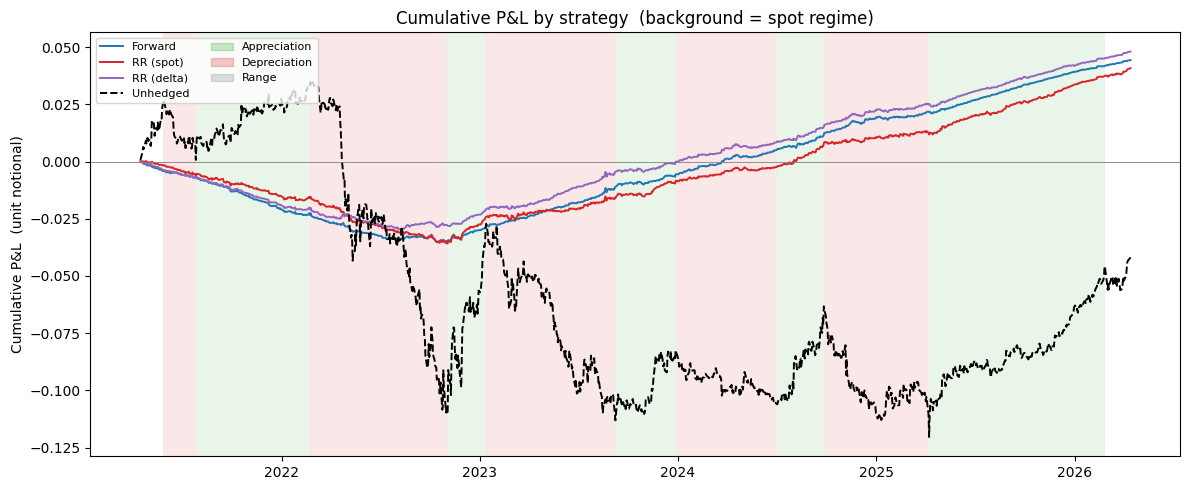

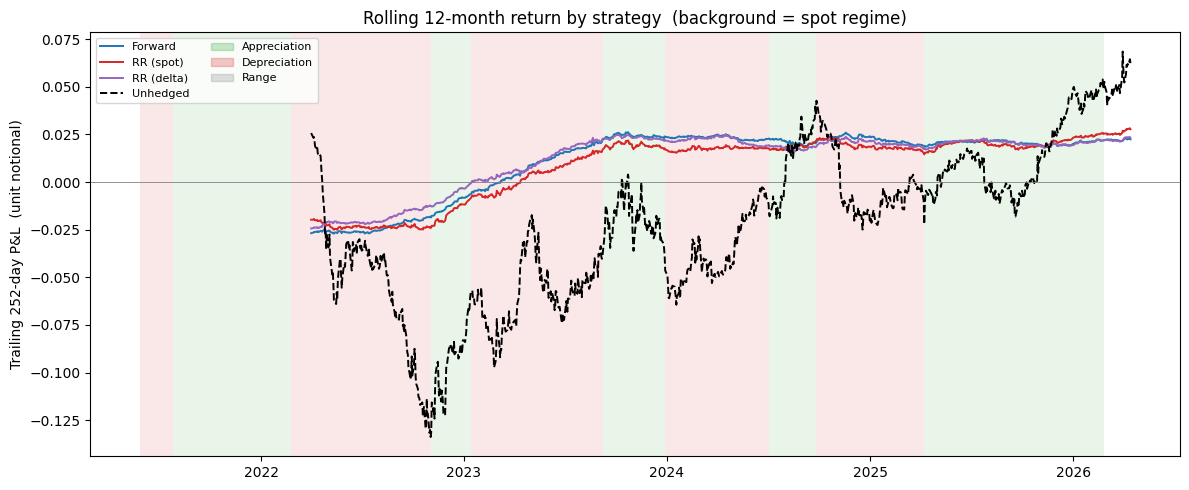

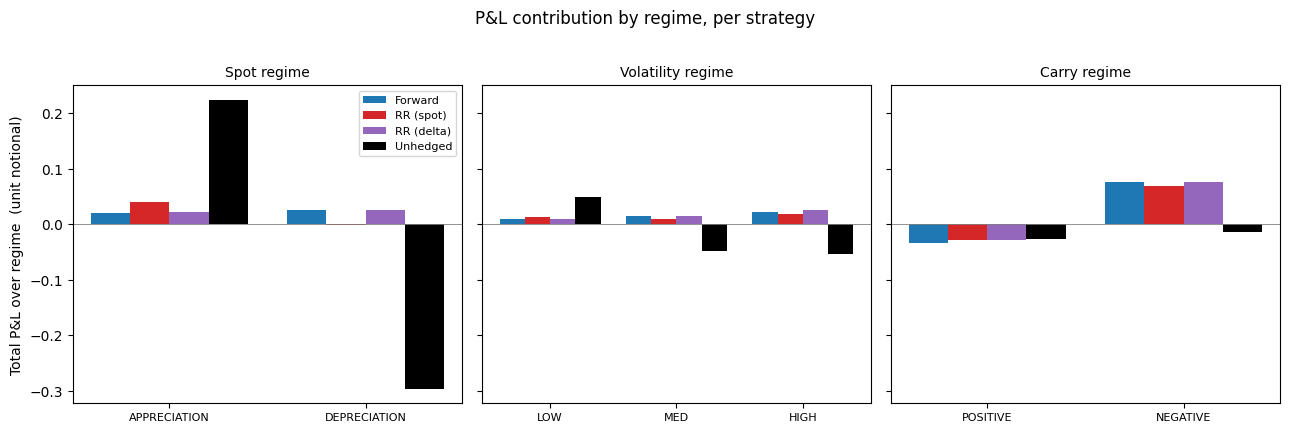

In [16]:
# --- Deterministic descriptives: summary table + charts ----------------------
import importlib
import analysis, descriptives as dz
importlib.reload(analysis); importlib.reload(dz)

# Reuse the master frame from the main analysis run.
# If not already built:
#   res = analysis.run_all(B=10_000, frames=frames, spot_dates=spot_df["Pricing_Date"])
master = res["master"]

# 1. Deterministic summary table (no inference) -------------------------------
summary = dz.summary_table(master)
summary.to_csv("descriptive_summary.csv", index=False)
display(summary.round(4))

# 2. Charts -------------------------------------------------------------------
fig_cum    = dz.plot_cumulative_pnl(master)      # cumulative P&L, regime-shaded
fig_roll   = dz.plot_rolling_return(master)      # rolling 12-month return
fig_bars   = dz.plot_regime_pnl_bars(master)     # P&L by regime, per strategy

# Save for the write-up
fig_cum.savefig("cum_pnl.png",          dpi=150, bbox_inches="tight")
fig_roll.savefig("rolling_return.png",  dpi=150, bbox_inches="tight")
fig_bars.savefig("regime_pnl_bars.png", dpi=150, bbox_inches="tight")

plt.show()   # with %matplotlib inline all three render in the notebook

## Spread Analysis: delta rr and forward

SPREAD REPORT:  RR (delta)  vs  Forward   (positive = RR (delta) ahead)
Full sample: 1296 days
  cumulative edge   : +37.3 bps of notional over the sample
  annualised edge   : +7.3 bps/yr
  information ratio : +0.34   (consistency of the edge)
  daily hit rate    : 48.6%
  spread max drawdown: 52.4 bps  (worst stretch of RR (delta) trailing Forward)

Monthly: 61 months | hit rate 57% | avg +0.6 bps/mo | IR +0.32
  best/worst month  : +24.1 / -22.8 bps

Per-regime spread (bps):
           regime    n  cum_spread_bps  ann_mean_bps  info_ratio hit_rate  spread_max_dd_bps
             full 1296            37.3           7.3        0.34      49%               52.4
spot:APPRECIATION  571            23.3          10.3        0.64      52%               17.1
spot:DEPRECIATION  660             6.9           2.6        0.10      45%               42.0
          vol:LOW  425            -4.1          -2.4       -0.20      48%               29.9
          vol:MED  425            -0.9          -0.5

,regime,n,cum_spread_bps,ann_mean_bps,ann_vol_bps,info_ratio,hit_rate,spread_max_dd_bps
0,full,1296,37.30561,7.25387,21.27189,0.34101,0.48611,52.37464
1,spot:APPRECIATION,571,23.26524,10.26767,15.94495,0.64394,0.52014,17.05682
2,spot:DEPRECIATION,660,6.85415,2.61704,25.45079,0.10283,0.45000,42.02193
3,vol:LOW,425,-4.05456,-2.40412,12.31445,-0.19523,0.48235,29.90778
4,vol:MED,425,-0.91850,-0.54461,16.37031,-0.03327,0.47294,21.99137
5,vol:HIGH,426,37.45358,22.15564,30.81688,0.71895,0.50000,29.28876
6,carry:POSITIVE,319,49.32996,38.96912,23.98202,1.62493,0.51724,16.11750
7,carry:NEGATIVE,977,-12.02434,-3.10147,20.27971,-0.15293,0.47595,52.37464


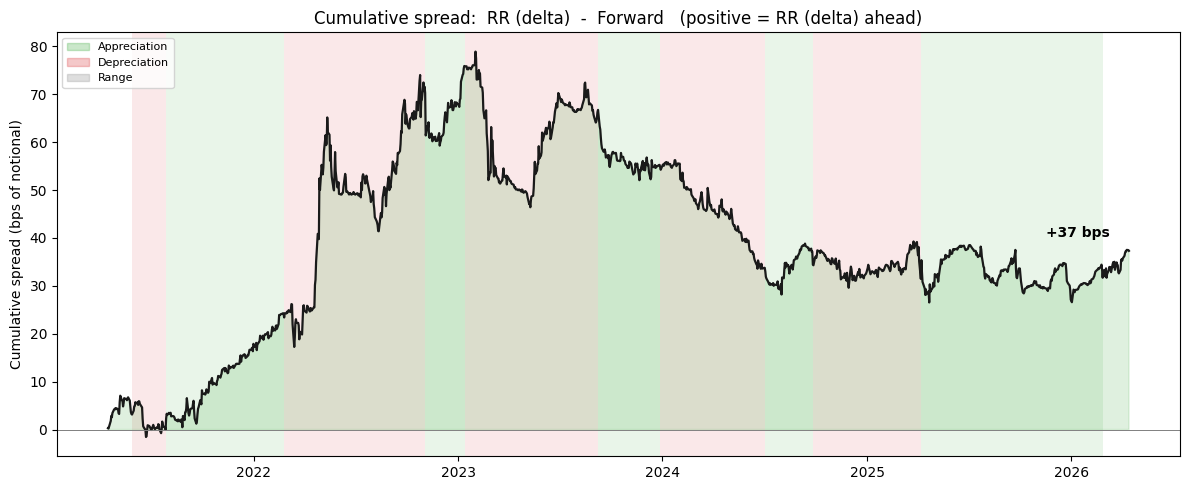

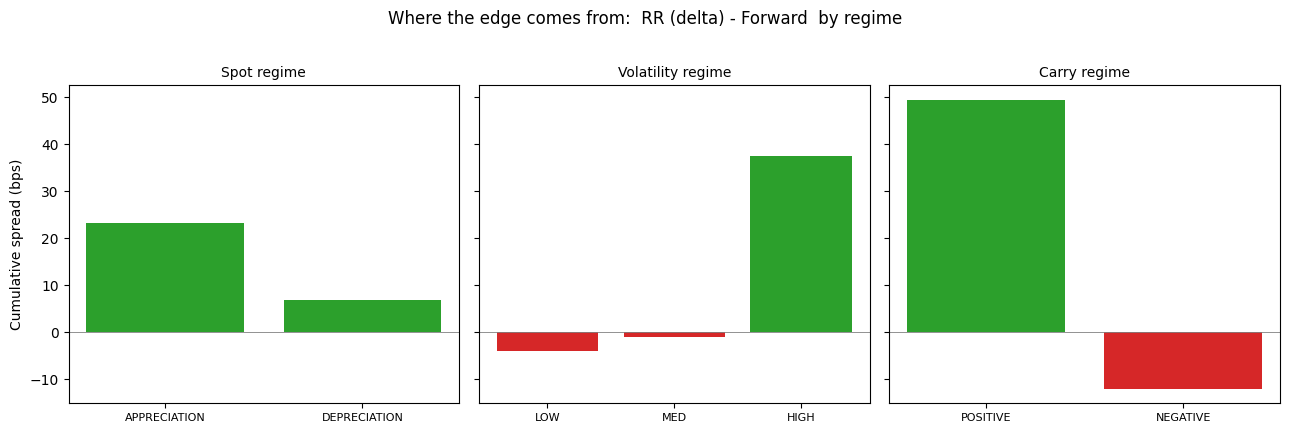

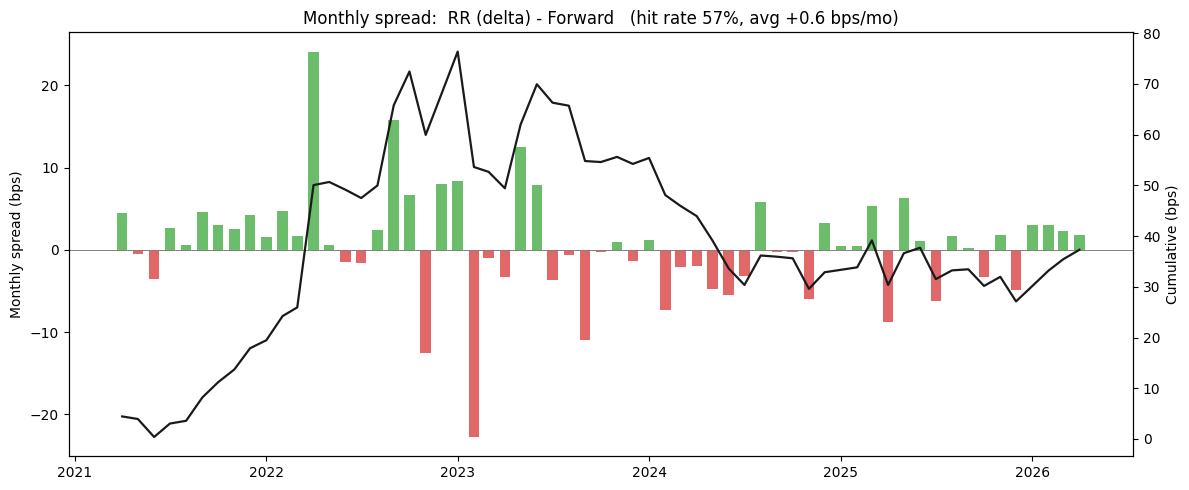

In [17]:
# --- Spread analysis: delta RR vs forward (descriptive, no inference) ---------
import analysis, spread_analysis as sp

master = res["master"]   # from analysis.run_all(...)

# Full report: prints the summary, returns tables + figures
spread = sp.run_spread_report(master, leg="ret_rr_delta", base="ret_forward")

# Tables for the write-up
spread_table   = spread["table"]            # per-regime IR / hit rate / drawdown
monthly_series = spread["monthly"]          # monthly spread in bps
monthly_stats  = spread["monthly_summary"]  # monthly hit rate, avg, IR

display(spread_table.round(5))

# Save the three figures
spread["figs"]["cumulative"].savefig("spread_cumulative.png", dpi=150, bbox_inches="tight")
spread["figs"]["regime"].savefig("spread_regime.png",         dpi=150, bbox_inches="tight")
spread["figs"]["monthly"].savefig("spread_monthly.png",       dpi=150, bbox_inches="tight")

plt.show()

# (Optional) the same lens on the spot RR, for contrast:
# spread_spot = sp.run_spread_report(master, leg="ret_rr_spot", base="ret_forward")

## Spread analysis: spot rr and forward

SPREAD REPORT:  RR (spot)  vs  Forward   (positive = RR (spot) ahead)
Full sample: 1296 days
  cumulative edge   : -35.1 bps of notional over the sample
  annualised edge   : -6.8 bps/yr
  information ratio : -0.17   (consistency of the edge)
  daily hit rate    : 47.0%
  spread max drawdown: 174.6 bps  (worst stretch of RR (spot) trailing Forward)

Monthly: 61 months | hit rate 49% | avg -0.6 bps/mo | IR -0.16
  best/worst month  : +26.1 / -32.4 bps

Per-regime spread (bps):
           regime    n  cum_spread_bps  ann_mean_bps  info_ratio hit_rate  spread_max_dd_bps
             full 1296           -35.1          -6.8       -0.17      47%              174.6
spot:APPRECIATION  571           205.3          90.6        2.36      54%               20.7
spot:DEPRECIATION  660          -271.3        -103.6       -2.66      39%              272.7
          vol:LOW  425            33.1          19.6        0.70      50%               43.4
          vol:MED  425           -47.6         -28.2  

,regime,n,cum_spread_bps,ann_mean_bps,ann_vol_bps,info_ratio,hit_rate,spread_max_dd_bps
0,full,1296,-35.08,-6.82,39.04,-0.17,0.47,174.62
1,spot:APPRECIATION,571,205.27,90.59,38.35,2.36,0.54,20.72
2,spot:DEPRECIATION,660,-271.32,-103.60,38.93,-2.66,0.39,272.75
3,vol:LOW,425,33.11,19.63,28.22,0.70,0.50,43.38
4,vol:MED,425,-47.64,-28.25,36.47,-0.77,0.47,93.12
5,vol:HIGH,426,-36.33,-21.49,49.45,-0.43,0.43,75.00
6,carry:POSITIVE,319,40.87,32.29,36.89,0.88,0.53,37.31
7,carry:NEGATIVE,977,-75.95,-19.59,39.71,-0.49,0.45,144.87


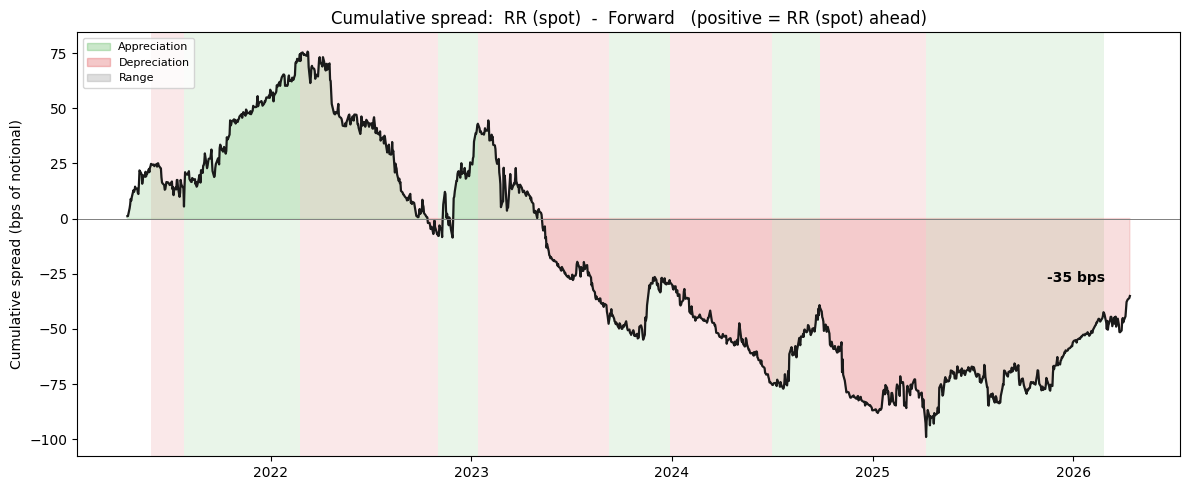

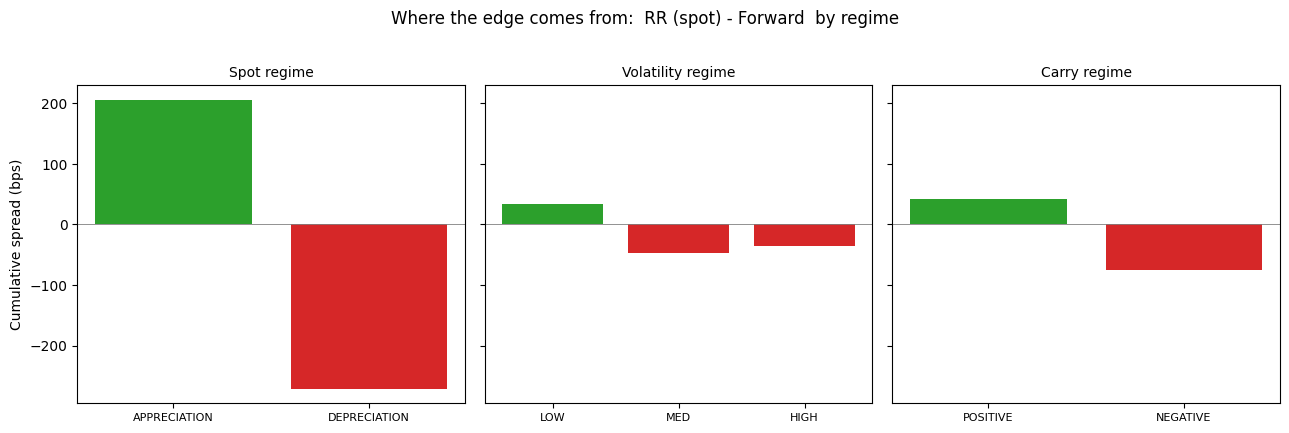

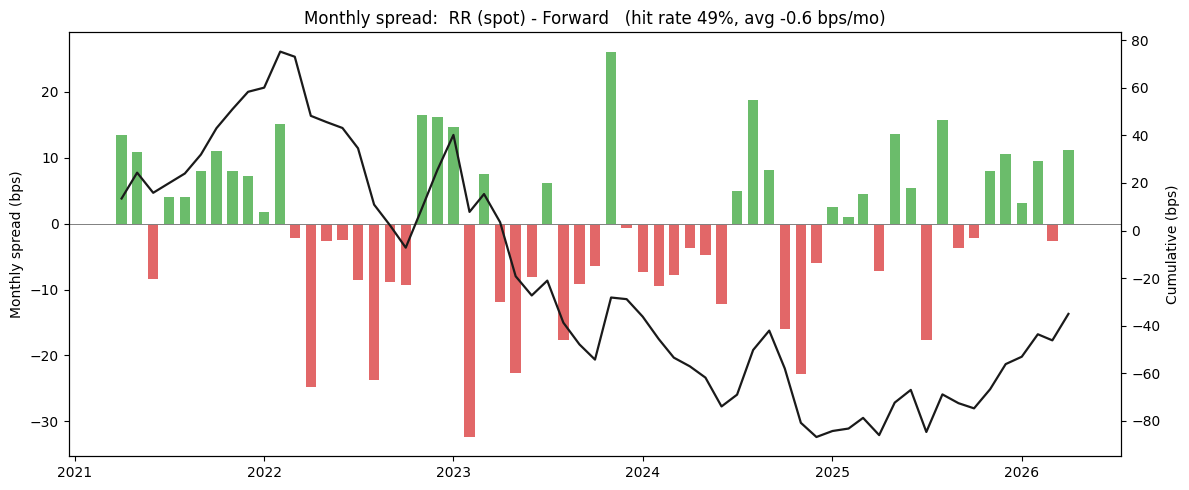

In [18]:
# --- Spread analysis: delta RR vs forward (descriptive, no inference) ---------
import analysis, spread_analysis as sp

master = res["master"]   # from analysis.run_all(...)

# Full report: prints the summary, returns tables + figures
spread = sp.run_spread_report(master, leg="ret_rr_spot", base="ret_forward")

# Tables for the write-up
spread_table   = spread["table"]            # per-regime IR / hit rate / drawdown
monthly_series = spread["monthly"]          # monthly spread in bps
monthly_stats  = spread["monthly_summary"]  # monthly hit rate, avg, IR

display(spread_table.round(2))

# Save the three figures
spread["figs"]["cumulative"].savefig("spread_cumulative.png", dpi=150, bbox_inches="tight")
spread["figs"]["regime"].savefig("spread_regime.png",         dpi=150, bbox_inches="tight")
spread["figs"]["monthly"].savefig("spread_monthly.png",       dpi=150, bbox_inches="tight")

plt.show()

# (Optional) the same lens on the spot RR, for contrast:
# spread_spot = sp.run_spread_report(master, leg="ret_rr_spot", base="ret_forward")

## Bootstrap: spot vs delta rr

In [19]:
# --- Direct paired bootstrap: delta RR vs spot RR ----------------------------
import pairwise_bootstrap as pb

master = res["master"]

delta_vs_spot, dist, block = pb.bootstrap_pairwise(
    master, leg="ret_rr_delta", base="ret_rr_spot", B=10_000
)
delta_vs_spot.to_csv("delta_vs_spot_bootstrap.csv", index=False)

# Headline regimes
for rk in ["full", "spot:APPRECIATION", "spot:DEPRECIATION"]:
    print(f"\n--- {rk} ---")
    display(delta_vs_spot[delta_vs_spot["regime"] == rk]
            [["metric","point","ci_lo","ci_hi","verdict"]])

rr_delta - rr_spot | B=10000 | block=63 (Politis-White=1.7, floored at 63)

--- full ---


,metric,point,ci_lo,ci_hi,verdict
0,ann_mean,0.001407,-0.002393,0.005610,inconclusive
1,cvar95_reduction,0.000166,0.000096,0.000225,rr_delta better
2,mdd_reduction,0.006571,-0.005224,0.016239,inconclusive
3,upside_part,-0.081296,-0.091228,-0.075604,rr_spot better



--- spot:APPRECIATION ---


,metric,point,ci_lo,ci_hi,verdict
4,ann_mean,-0.008033,-0.012196,-0.005207,rr_spot better
5,cvar95_reduction,0.000166,0.000096,0.000232,rr_delta better
6,mdd_reduction,-0.003203,-0.008291,0.000742,inconclusive
7,upside_part,-0.081199,-0.098739,-0.073318,rr_spot better



--- spot:DEPRECIATION ---


,metric,point,ci_lo,ci_hi,verdict
8,ann_mean,0.010621,0.006148,0.015194,rr_delta better
9,cvar95_reduction,0.000185,0.000063,0.000257,rr_delta better
10,mdd_reduction,0.012714,0.000573,0.028106,rr_delta better
11,upside_part,-0.082617,-0.092404,-0.076118,rr_spot better


Cost-unit construction (roll_fraction=0.3333 = 1/3 of the book per roll):
  forward   rolls= 60  legs/roll=1  book notional~0.941  traded/roll~0.314
  rr_spot   rolls= 60  legs/roll=2  book notional~0.941  traded/roll~0.314
  rr_delta  rolls= 60  legs/roll=2  book notional~1.031  traded/roll~0.344
  sample years~5.00  roll events/yr: fwd=12.0, rr_spot=12.0, rr_delta=12.0

Bootstrap net of 0.50 bps/option-leg/roll (forward 0.00) | block=63 | B=10000
Bootstrap net of 1.00 bps/option-leg/roll (forward 0.00) | block=63 | B=10000
Bootstrap net of 2.00 bps/option-leg/roll (forward 0.00) | block=63 | B=10000

HEADLINE BREAK-EVENS  (option cost, bps per leg per roll)
    comparison            regime  gross_ann_mean_bps  breakeven_bps_per_leg_roll  breakeven_bps_notional_per_yr                 status
rr_delta - fwd              full                 7.3                        0.91                            7.5 break-even within grid
rr_delta - fwd spot:APPRECIATION                10.3          

,comparison,regime,metric,gross_value,breakeven_bps_per_leg_roll,breakeven_bps_notional_per_yr,status
0,rr_delta - fwd,full,ann_mean,0.0007,0.9054,7.4693,break-even within grid
1,rr_delta - fwd,full,cvar95_reduction,-0.0001,0.0000,0.0000,negative at zero cost
2,rr_delta - fwd,full,mdd_reduction,0.0055,4.6592,38.4377,break-even within grid
3,rr_delta - fwd,full,upside_part,-0.0054,0.0000,0.0000,negative at zero cost
4,rr_delta - fwd,spot:APPRECIATION,ann_mean,0.0010,1.2968,10.6987,break-even within grid
5,rr_delta - fwd,spot:APPRECIATION,cvar95_reduction,-0.0000,0.0000,0.0000,negative at zero cost
6,rr_delta - fwd,spot:APPRECIATION,mdd_reduction,0.0020,3.3703,27.8043,break-even within grid
7,rr_delta - fwd,spot:APPRECIATION,upside_part,-0.0029,0.0000,0.0000,negative at zero cost
8,rr_delta - fwd,spot:DEPRECIATION,ann_mean,0.0003,0.3238,2.6713,break-even within grid
9,rr_delta - fwd,spot:DEPRECIATION,cvar95_reduction,-0.0001,0.0000,0.0000,negative at zero cost


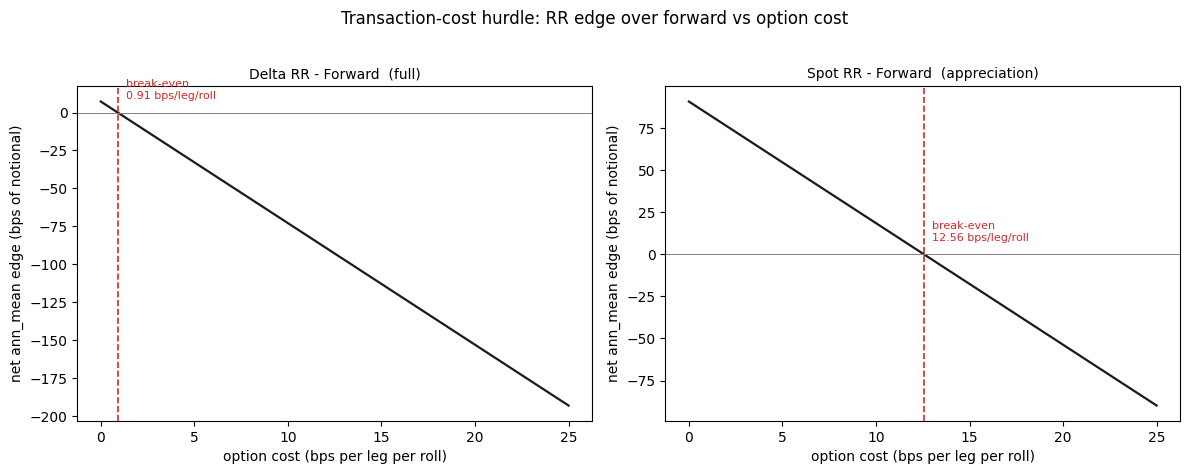

In [20]:
import transaction_cost_analysis as tca

paths = {
    "forward":  "Regimes/hedged_forward_spot_regimes.csv",
    "rr_spot":  "Regimes/hedged_rr45_spot_regimes.csv",
    "rr_delta": "Regimes/hedged_rr45_delta_regimes.csv",
    "unhedged": "Regimes/unhedged_regimes.csv",
}
frames  = {k: pd.read_csv(p) for k, p in paths.items()}
spot_df = pd.read_csv("Market Data/spot_price.csv")
spot_df["Pricing_Date"] = pd.to_datetime(spot_df["Pricing_Date"], dayfirst=True)

res = tca.run_cost_analysis(
    frames, spot_df["Pricing_Date"],
    cost_bps_forward=0.0,        # forward free -> isolates the option-cost hurdle
    roll_fraction=1/3,           # 1/3 of book per roll (set 1.0 for full-notional convention)
    boot_costs=(0.5, 1.0, 2.0),
    B=10_000,
)
display(res["breakeven"].round(4))
fig = tca.plot_breakeven(res["sweep"], res["breakeven"]); fig.savefig("cost_breakeven.png", dpi=120, bbox_inches="tight")

## Rolling Window

There is leakage due to staggered expiries
Each rolling window needs to be a new set of strategies

Every entry (new start date), there is a 1 month, 2 month exposure pair in the other positions
-> just like the start when you wait until position is fully settled into 

t0 -------- t1 ------ t2 ------ t3 ------- t4 ------- t5 ------- t6
P1 >>>>>>>> New >>>>>>>>>>>>>>>>>>>>>>>>>>> New >>>>>>>>>>>>>>>>>>>>
P2 >>>>>>>>>>>>>>>>>> New >>>>>>>>>>>>>>>>>>>>>>>>>>> New >>>>>>>>>>
P3 >>>>>>>>>>>>>>>>>>>>>>>>>>>> New >>>>>>>>>>>>>>>>>>>>>>>>>>>> New

                                ^ start fold 1 from here [Month 3]


t15 -------- t16 ------ t17 ------ t18 ------- t19 ------- t20 ------- t21
P1>>>>>>>>>> New >>>>>>>>>>>>>>>>>>>>>>>>>>>>> New >>>>>>>>>>>>>>>>>>>>>>>
P2>>>>>>>>>>>>>>>>>>>>> New >>>>>>>>>>>>>>>>>>>>>>>>>>>>>> New >>>>>>>>>>>
New >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>> New >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>> New

^ end fold              ^ start fold 2 [no overlapping positions with previous fold]

OVERLAP

Choosing which type of data analysis to run (I was originally thinking rolling windows only):

There's a better alternative: keep all the overlapping windows for analysis and visualization, then handle the autocorrelation at the inference stage using methods like Newey–West standard errors or block bootstrap with block lengths matching the contract tenor. 

The real choice isn't between leakage and tiny sample sizes; it's between throwing away data or using the right statistical tools to account for dependence.

The real question is what's being estimated in-sample. If nothing, it's overlap not leakage, and the solution is different and less destructive to the data.

"Leakage" in the strict sense means information from a test period influences something you fit and then evaluate on overlapping data. That only bites if you're estimating parameters in-sample (a vol-surface model, an optimal delta, a hedge ratio) and scoring on the same span.

If nothing is fit per window, then what you have is not leakage — it's overlap-induced dependence between window statistics. 

The cost of overlap is only that you can't treat windows as independent draws in a significance test. 

The standard fix in empirical finance for exactly this — overlapping returns — keeps all the data and handles dependence at the inference layer rather than by discarding it: run overlapping windows (monthly step) for the descriptive rolling-P&L picture, then for any formal comparison use a stationary/block bootstrap with block length ≥ one contract tenor (so the resampling preserves the roll-induced autocorrelation), or HAC/Newey–West standard errors. That gives you valid inference and the full series.

WINDOW LENGTH

Defensible, and your instinct to commit before seeing results is the right one. Twelve months spans a full annual cycle, smooths out roll-timing luck, and annualizes cleanly. The binding issue isn't the 12 itself — it's the ratio to your sample. Five years is ~60 months, so you get at most ~4–5 non-overlapping 12-month windows. That's far too few to treat as independent draws for any test of "strategy A beats B." And separately: over any recent 5-year USDCNH sample you're spanning genuinely different regimes (managed-fixing periods, the COVID shock, the 2022 weakening past 7.3), so each 12-month window will be dominated by whatever regime it lands in. The windows won't be iid no matter how you space them — which is another argument against leaning on a small-n independent-window test.


METRICS

The underlying daily or per-pricing-date P&L series has its own dependence structure, but then they're aggregating these into 12-month windows, and those overlapping windows create autocorrelation in the window-level metrics themselves. This matters for how we interpret statistical significance and how we adjust for dependence. 

The asymmetry is the crux of it — the forward locks in a rate symmetrically while the risk reversal creates skew and tail exposure through its short option leg, which is exactly why standard mean and variance metrics miss the real difference.

**For tail metrics like CVaR and maximum drawdown, rolling-window estimation introduces too much noise; it's better to pool observations by regime or use the full 5-year sample and reserve rolling windows mainly for mean and variance.**

Maximum drawdown is particularly problematic — it's path-dependent with high sampling variability and non-stationary across windows, so comparing MDD across overlapping periods is descriptive only, and bootstrap methods are needed to construct confidence intervals around it.

the most theoretically relevant metric here is upside and downside participation — this directly tests whether the RR structure delivers the asymmetric payoff it promises. The forward should show near-zero participation in both directions (fully hedged, linear), while the RR should capture most upside moves when CNH strengthens but limit downside exposure. to define this precisely, either through capture ratios (mean hedged return in up markets divided by mean benchmark return in up markets) or conditional betas that isolate the hedged portfolio's sensitivity in bull versus bear regimes.

Variance reduction is a standard hedging metric, but it's inherently symmetric — I should pair it with tail-focused measures like CVaR reduction and drawdown reduction to get the full picture. The variance ratio itself requires careful inference since it's a ratio of dependent estimators, so bootstrapping the whole ratio is necessary.

What's really missing is skewness — the RR deliberately reshapes the return distribution to trade off some medium-sized losses for tail protection, creating skew, while the forward's linear payoff removes that skew entirely. Reporting skewness directly tests whether the payoff structure claim holds up. Higher moments are noisy, so I should pool observations by market regime to get cleaner estimates.

For risk-adjusted returns, Sortino ratio is more relevant than Sharpe here since it only penalizes downside volatility — directly aligned with the asymmetry focus. I'd use the Ledoit-Wolf circular-block-bootstrap test to compare Sortino across strategies, which properly handles time-series dependence.  

There are two layers: within-series dependence (autocorrelation and volatility clustering, which FX exhibits strongly) affects standard errors, vol annualization, and VaR estimation — I should use Newey-West or block bootstrap for these. Then there's cross-window dependence from the rolling-window overlap, where each window shares most of its data with neighbors, creating massive autocorrelation in the rolling-metric sequence itself.

So I need to avoid computing t-stats on overlapping window means as if they were iid. 

The key distinction: rolling windows show stability and time-variation descriptively; block bootstrap on the full or per-regime series gives me actual inference. I need to keep these separate and not mix them up.

FX tails widen during stress regimes so regime-specific analysis is critical

For the risk metrics themselves, I should use mark-to-market returns rather than realized P&L, since realized-only captures lumpy roll events and misses the interim path volatility that matters for VaR and drawdown analysis.

realised P&L is lumpy (it only prints at rolls), so it understates interim risk and will flatter the RR strategies.

Mean, variance, and the variance-reduction ratio are stable and fine to compute per 12-month window. The 95/99% CVaR and maximum drawdown are not. Max drawdown is a single path-extreme per window with a hugely skewed sampling distribution.

Variance and the variance-reduction ratio (Ederington hedging effectiveness, 1 − Var_hedged/Var_unhedged) treat upside and downside identically. That's exactly right for the forward, which is linear, and exactly wrong for the risk reversal, which is built to be asymmetric — so a variance-only lens will under-differentiate the two RR strategies and miss the whole point of your theory comparison.

!!! The forward collapses the whole distribution to a point (flat line), so it lives entirely in mean and variance. The risk reversal retains a band of exposure and truncates the tails asymmetrically — and because the CNH risk-reversal market itself trades with a pronounced skew (USD-call protection is bid), the two strikes aren't symmetric about the forward, so the truncation is lopsided. That asymmetry shows up in skewness, in tail measures, and in up-versus-down participation — not in variance. 

Within the return series, FX returns have mild autocorrelation and strong volatility clustering. (check)

Rolling windows are for description: plot rolling volatility, rolling Sortino, rolling variance-reduction over time to show stability and regime sensitivity. Do not derive p-values from that series.

Tail and path metrics don't get rolling charts at all because a single window's estimate would be too noisy to be meaningful.

For inference — every "A beats B" claim — work on the full (and per-regime) return series

Every metric — stable moments and tail/path alike — takes its point estimate and its bootstrap or HAC inference from the pooled full sample and from each regime slice. That is the single source of truth for every number you report and every A-versus-B comparison you make.

Rolling windows do exactly one job: visualising how the stable moments drift over time (rolling volatility, rolling Sharpe, rolling variance-reduction). They never feed an estimate or a test.


NEW METRICS

Skewness, and kurtosis as a secondary. The single most direct test of "did the RR reshape the distribution as theory predicts." Report it but estimate it on pooled/regime data — higher moments are noisy per window.

Sortino ratio alongside Sharpe. Sharpe penalises upside volatility, which unfairly dings an asymmetric hedge that retains favourable moves; Sortino only penalises downside deviation and is the better risk-adjusted lens here.

Tail-reduction and drawdown-reduction ratios, built parallel to your variance-reduction ratio: 1 − CVaR_hedged/CVaR_unhedged and the analogous drawdown ratio. Presenting variance-, tail-, and drawdown-reduction side by side is where the story lands — the forward should reduce variance most and uniformly; the RR should reduce tail risk while preserving more upside, and the gap between the variance and tail rankings is your evidence of payoff-structure difference.

Calmar (annualised return over max drawdown) to tie return to the worst path.

Make participation a conditional regression rather than a raw capture ratio: regress each hedged return on the unhedged benchmark and on the benchmark interacted with a down-state indicator (a Henriksson–Merton style up/down beta). That gives you separate up- and down-betas with HAC-adjusted t-stats, so "the RR participates asymmetrically" becomes a tested coefficient, not an eyeballed ratio. The forward should show both betas near zero; the RR should show a clear up/down asymmetry, and the delta hedge a stronger one than the spot hedge given its larger option notional.

the gap between CVaR and VaR is itself a compact diagnostic of tail shape: for the linear forward the two sit close together, while for the RR the short-put tail pulls CVaR away from VaR

So the stable-versus-tail distinction now governs only one thing: whether a metric is worth putting on a rolling chart at all. Stable moments are — their per-window values are meaningful enough to trace a time path. Tail and path metrics (CVaR, max drawdown) aren't charted on a rolling basis at all, because a single 12-month window doesn't hold enough tail observations for the per-window number to mean anything. Where the actual estimates and inference come from doesn't change between the two groups — it's full-sample-plus-regime for everything.


DELTA NOTIONAL

So the delta hedge requires a larger RR notional to match the physical's delta sensitivity, while the spot hedge just matches face value—meaning the delta hedge carries more option exposure and thus stronger convexity effects. 

it explains why the delta hedge will likely show more pronounced asymmetry and tail behavior in the results. 

forward-versus-RR is the payoff-shape comparison, but spot-hedge-versus-delta-hedge is mostly a sizing/convexity comparison (same structure, more options in the delta hedge). Keep those two contrasts separate in the discussion so the theory match is clean.


BOOTSTRAPPING AND CONFIDENCE INTERVALS

The block bootstrap is the principled version of what window-aggregation gropes toward: it resamples blocks to build the distribution of the statistic across hypothetical re-draws, correctly preserving dependence. That's why the division of labour is rolling windows for the time-variation picture, full-sample bootstrap for the numbers — not because rolling windows are wrong, but because for your setup their only remaining job is showing how things move over time.

Bootstrapping is a general-purpose way to approximate the sampling distribution of any statistic

For dependent data like yours, you resample contiguous blocks instead of individual points so the serial dependence survives the resampling — that's the only modification.

f you only describe — "over this sample, strategy A had lower realised variance than B" — that's a statement of fact about a known path and needs no interval. But the moment you write "A reduces risk more than B" as a property of the strategies, you've stopped describing and started generalising: you're impliciItly saying the gap reflects something real about the strategies, not an accident of these particular five years. 

You do not need to bootstrap every cell of every table — put intervals on the few comparisons you actually conclude from (variance reduction, tail reduction, the Sharpe/Sortino difference, the up/down participation betas) and report the rest as descriptive point estimates.

treat your sample as one draw from a stochastic FX process and infer properties of the strategies, rather than only cataloguing one path.

!!! I'm assuming approximate stationarity over whatever stretch you bootstrap — that the statistical behaviour is stable enough there that resampling from the observed data is a fair stand-in for the true process. For USDCNH across a multi-year span this is shaky, because the pair has regime shifts (managed-float policy changes, crises) where the distribution genuinely changes. That fragility is the real reason I keep pushing the by-regime analysis: within a single regime, approximate stationarity is far more plausible, so bootstrap intervals computed within regime are much more defensible than one interval spanning the whole mixed history.

I'm assuming you have enough data to estimate the statistic in the first place. That holds comfortably for means and variances. It does not hold for 99% CVaR or maximum drawdown, where even the point estimate is unstable — there the bootstrap will return a very wide interval, and that width is itself the finding: "with this much data we cannot distinguish the strategies' tail behaviour." The bootstrap never manufactures information it doesn't have.

HAC t-statistics for the participation regression and the Ledoit–Wolf test for the Sharpe difference earlier, those aren't a different framework — they're just the route that fits each metric. A regression coefficient comes naturally as estimate, standard error, t-statistic; an awkward ratio comes naturally as a percentile interval.

Means, variances, and the ratios built on them are data-cheap, so they live everywhere. Tail and path statistics (CVaR, drawdown, and anything built on them, including Calmar) are data-hungry extremes — a per-window estimate is too noisy to mean anything, which is why they're full-and-regime only.

when bootstrapping comparison metrics, resample the underlying path once, compute all three strategies on that same resampled path, then take the differences. This preserves the correlation between strategies (they all share the same USDCNH moves) and gives far tighter inference on the differences than bootstrapping each strategy independently would.

Bootstrap the differences jointly, not each strategy on its own. All three strategies sit on the same USDCNH path, so they're highly correlated, and the comparative claims are about differences (variance-reduction A vs B, Sharpe A vs B, etc.). Resample once, recompute all three strategies on that same resampled path, take the difference, and build the distribution of the difference. Do not bootstrap each strategy's metric independently and then check whether their intervals overlap — overlapping individual CIs do not mean "no difference" when the estimates are correlated, and you'd throw away most of your power. The Ledoit–Wolf Sharpe test already does this paired resampling internally; mirror that logic for the other comparisons.

Across metrics × regimes × strategy pairs you'll run a large grid of comparisons, and some will look significant by chance. Pre-specify the few headline comparisons your thesis actually argues from and treat the rest as supporting/descriptive, rather than hunting the grid for stars 


FORWARD POINTS AND MARKET SKEW

What forward points actually are is the embedded carry — the interest-rate differential baked into the forward rate


FINDING REGIMES

regimes need to come from structural market conditions defined upfront, not from reverse-engineering what worked in the strategy's P&L

Data-driven regime detection on market fundamentals like spot, vol, and rate differentials is defensible since those variables are independent of strategy choice, though there's still a mild over-fitting concern when applied to the same test period.

For USDCNH specifically, the key regime drivers are policy-based — PBoC's management style, fixing regime, trading bands, and major events like the 2015 devaluation, 2016 depreciation pressure, trade war episodes, and the 2022-24 weakness as USD rates climbed and the currency broke through key levels like 7.0 and 7.30.

The rate differential regime is particularly clean and exogenous: pre-2022, CNH rates typically exceeded USD rates (positive carry), but after the Fed's hiking cycle flipped that relationship, which directly affects forward points and the hedge's carry profile. 

Volatility regimes — both realized and implied, plus the risk-reversal skew — also matter significantly since the RR strategy's payoff depends on skew levels and whether the market is pricing crash risk or trading flat.

The hybrid approach is probably strongest for a thesis: define regimes on exogenous grounds (carry sign, vol state, documented events), then validate them against a data-driven break test to show the structural boundaries align with statistical breaks. This gives both defensibility and empirical backing.

Detecting regimes from the underlying USDCNH series (spot, vol, skew, carry) is fine, because those are common to all three strategies and independent of which hedge you ran. 



My data: 5 years of daily marked to market data for three strategies

Metrics:

Annualised Mean Return

Variance / Volatility

Variance reduction ratio


TAIL RISK

CVaR 99%

CVaR 95%

VaR 95 / 95% for reference

Tail-reduction ratio (CVaR based)


PATH RISK

Maximum drawdown

Drawdown-reduction ratio

Calmar (return / MDD)


DISTRIBUTION SHAPE

Skewness

Kurtosis (secondary)

Up / down participation (conditional betas)


RISK-ADJUSTED RETURN

Sharpe Ratio

Sortino Ratio

Sharpe/Sortino difference



AMP FLOOR NOTES

The floor is the entire mechanism by which your third state exists, so its value is not a minor tuning knob, it defines RANGE.

Amplitude floor conflates "small total move" with "directionless," and those aren't the same.